# Neural Network for Binary Image Classification (Cats vs Dogs)

In this notebook, we implement and train a **fully-connected feedforward neural network** to classify images as **Cat** or **Dog**.

---

## Architecture Overview

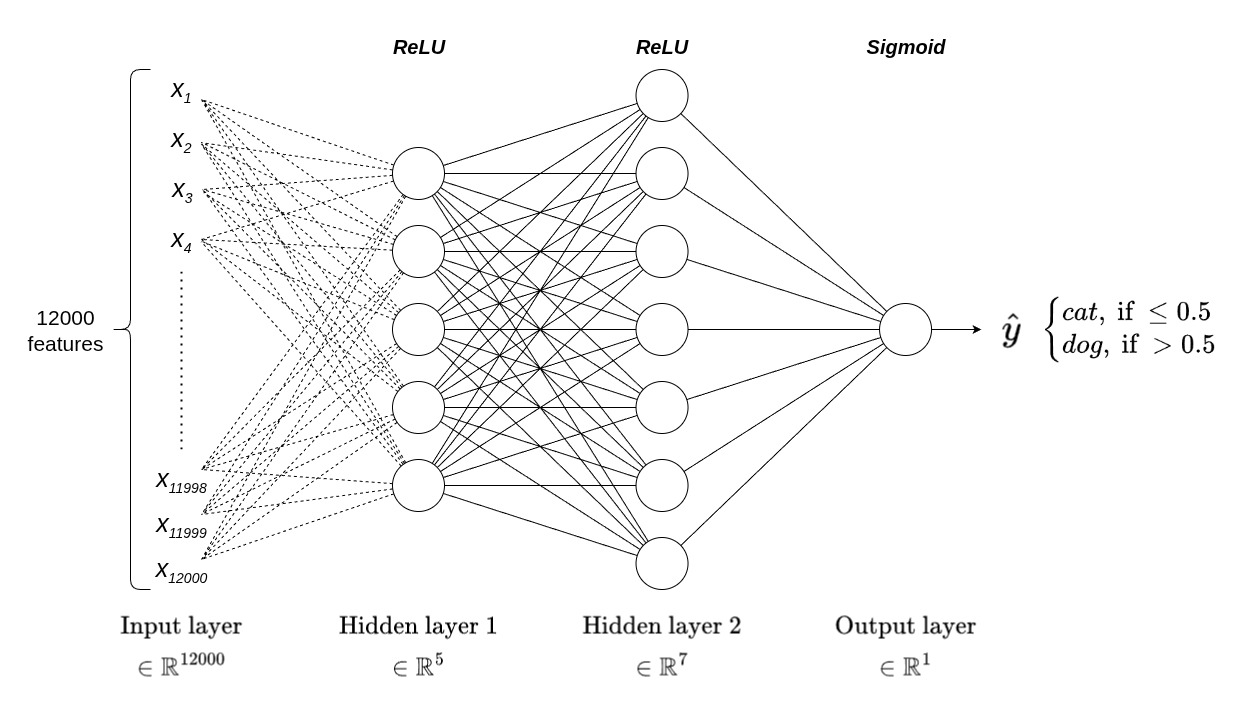

**Input Layer:**
- Each image is preprocessed and **flattened** into a vector of **12,000 features**.
- These features represent pixel intensity values.

**Hidden Layer 1:**
- **5 neurons**
- Fully connected to all 12,000 input features.
- Activation function: ReLU (or Sigmoid).
- Learns **low-level patterns** from raw pixel data.

$$
\text{ReLU}(z) =
\begin{cases}
z, & \text{if } z > 0 \\
0, & \text{if } z \le 0
\end{cases}
$$


**Hidden Layer 2:**
- **7 neurons**
- Fully connected to Layer 1.
- Extracts **higher-level combinations** of patterns.

**Output Layer:**
- **1 neuron** with **Sigmoid activation**:
  
  $$
  \hat{y} = \sigma(z) = \frac{1}{1 + e^{-z}}
  $$

- Outputs a probability between 0 and 1:
  - **0 → Cat**
  - **1 → Dog**

---

## Loss Function

We use **Binary Cross-Entropy (Log Loss)**:

$$
J = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log(\hat{y}^{(i)}) + (1 - y^{(i)}) \log(1 - \hat{y}^{(i)}) \right]
$$

Where:
- \( m \) = number of training examples  
- \( $y^{(i)}$ \) = actual label (0 for Cat, 1 for Dog)  
- \( $\hat{y}^{(i)}$ \) = predicted probability from the network

---

## Training Process

1. **Forward Propagation:** Pass the input through all layers to get predictions.
2. **Loss Computation:** Compare predictions with actual labels using Binary Cross-Entropy.
3. **Backward Propagation:** Calculate gradients for each weight using the chain rule.
4. **Parameter Update:** Update weights and biases using gradient descent.
5. Repeat for all epochs until the loss converges.

---

In [1]:
import os
import math
import random
import pickle

import numpy as np
import cupy as cp # Numpy alternative for GPU

import matplotlib.pyplot as plt

from PIL import Image

In [2]:
"""Shapes of metrices"""

# X -> (n, m)

# W1 -> (n1, n)
# b1 -> (n1, 1)
# z1 -> (n1, m)
# a1 -> (n1, m)

# w2 -> (n2, n1)
# b2 -> (n2, 1)
# z2 -> (n2, m)
# a2 -> (n2, m)

# w3 -> (1, n2)
# b3 -> (1, 1)
# z3 -> (1, m)
# a3 -> (1, m)

# Y -> (1, m)

'Shapes of metrices'

In [3]:
def relu(x):
    """Returns ReLU function output for given input x."""
    return cp.maximum(0, x)

In [4]:
def sigmoid(x):
    """Returns Sigmoid function output for given input x."""
    return 1 / (1 + cp.exp(-x))

## Forward Pass

The forward pass computes the activations of each layer from the input \( X \) to the output \( $\hat{y}$ \).

1. **First Hidden Layer (ReLU)**  
   $$
   Z^{[1]} = W^{[1]} X + b^{[1]}
   $$
   $$
   A^{[1]} = \text{ReLU}(Z^{[1]}) = \max(0, Z^{[1]})
   $$

2. **Second Hidden Layer (ReLU)**  
   $$
   Z^{[2]} = W^{[2]} A^{[1]} + b^{[2]}
   $$
   $$
   A^{[2]} = \text{ReLU}(Z^{[2]})
   $$

3. **Output Layer (Sigmoid)**  
   $$
   Z^{[3]} = W^{[3]} A^{[2]} + b^{[3]}
   $$
   $$
   \hat{y} = A^{[3]} = \sigma(Z^{[3]}) = \frac{1}{1 + e^{-Z^{[3]}}}
   $$

---



In [5]:
def perform_forward_pass_on_layer(W, b, X, perform_relu=True):
    """Given W, b, and X, apply dot matrix mutiplication to calculate z, and then optionally perform ReLU activation on z."""
    z = cp.dot(W, X) + b
    if perform_relu:
        A = relu(z)
        return A
    return z

In [6]:
def perform_forward_pass(X, W1, b1, W2, b2, W3, b3):
    """Perform full forward pass on all 3 layers. ReLU is used only for first 2 layers, and sigmoid for the last layer."""
    A1 = perform_forward_pass_on_layer(W1, b1, X)
    A2 = perform_forward_pass_on_layer(W2, b2, A1)
    Zy = perform_forward_pass_on_layer(W3, b3, A2, perform_relu=False)
    Y = sigmoid(Zy)
    return A1, A2, Y


## Backpropagation

We compute gradients using the **chain rule** starting from the output layer and moving backward.

### 1️⃣ Output Layer (Sigmoid)
- Error at output:
  $$
  dZ^{[3]} = A^{[3]} - Y
  $$
- Gradients:
  $$
  dW^{[3]} = \frac{1}{m} dZ^{[3]} {A^{[2]}}^T
  $$
  $$
  db^{[3]} = \frac{1}{m} \sum_{i=1}^m dZ^{[3]}_i
  $$



In [7]:
def backpropagate_for_sigmoid(y, a3, a2, w3, b3, learning_rate):
    """Performs back propagation on the last layer and returns the derivative(dz3), and updated values of w3 and b3."""
    dz3 = a3-y    # dz3.shape = a3.shape: (1,m)
    dw3 = (1/m) * cp.matmul(dz3, a2.T) # dw3.shape: (1,n2) = avg((1,m)*(n2,m)).T
    db3 = (1/m)*(cp.sum(dz3, axis=1, keepdims=True)) # db3.shape: (1,1)
    w3 -= learning_rate * dw3 # w3.shape = dw3.shape: (1,n2)
    b3 -= learning_rate * db3 # b3.shape = db3.shape: (1,1)
    return w3, b3, dz3

### 2️⃣ Second Hidden Layer (ReLU)
- Backpropagate through \( $W^{[3]}$ \):
  $$
  dA^{[2]} = {W^{[3]}}^T dZ^{[3]}
  $$
- Apply ReLU derivative:
  $$
  dZ^{[2]} = dA^{[2]} \odot \mathbf{1}_{Z^{[2]} > 0}
  $$
- Gradients:
  $$
  dW^{[2]} = \frac{1}{m} dZ^{[2]} {A^{[1]}}^T
  $$
  $$
  db^{[2]} = \frac{1}{m} \sum_{i=1}^m dZ^{[2]}_i
  $$



In [8]:
def backpropagate_on_second_layer(w2, b2, w3, dz3, a2, a1, learning_rate):
    """Performs back propagation on the second layer and returns the derivative(dz2), and updated values of w2 and b2."""
    da2 = cp.matmul(w3.T, dz3) # da2.shape: (n2,m) = (n2,1)*(1,m)
    dz2 = da2 * cp.where(a2 > 0, 1, 0) # dz2.shape = da2.shape: (n2,m)
    dw2 = (1/m) * cp.matmul(dz2, a1.T) # dw2.shape: (n2,n1) = (n2,m) * (m,n1)
    db2 = (1/m) * cp.sum(dz2, axis=1, keepdims=True) # db2.shape: (n2,1) = avg(n2,m)
    w2 -= learning_rate * dw2 # w2.shape = dw2.shape: (n2,n1)
    b2 -= learning_rate * db2 # b2.shape = db2.shape: (n2,1)
    return w2, b2, dz2

### 3️⃣ First Hidden Layer (ReLU)
- Backpropagate through \( $W^{[2]}$ \):
  $$
  dA^{[1]} = {W^{[2]}}^T dZ^{[2]}
  $$
- Apply ReLU derivative:
  $$
  dZ^{[1]} = dA^{[1]} \odot \mathbf{1}_{Z^{[1]} > 0}
  $$
- Gradients:
  $$
  dW^{[1]} = \frac{1}{m} dZ^{[1]} X^T
  $$
  $$
  db^{[1]} = \frac{1}{m} \sum_{i=1}^m dZ^{[1]}_i
  $$

In [9]:
def backpropagate_on_first_layer(w1, b1, w2, dz2, a1, a0, learning_rate):
    """Performs back propagation on the first layer and returns the derivative(dz1), and updated values of w1 and b1."""
    da1 = cp.matmul(w2.T, dz2) # da1.shape: (n1,m) = (n1,n2)*(n2,m)
    dz1 = da1 * cp.where(a1 > 0, 1, 0) # dz1.shape = da1.shape: (n1,m)
    dw1 = (1/m) * cp.matmul(dz1, a0.T) # dw1.shape: (n2,n0) = (n1,m)*(m,n0)
    db1 = (1/m) * cp.sum(dz1, axis=1, keepdims=True) # db1.shape: (n1,1) = avg(n1,m)
    w1 -= learning_rate * dw1 # w1.shape = dw1.shape: (n1,n0)
    b1 -= learning_rate * db1 # b1.shape = db1.shape: (n1,1)
    return w1, b1, dz1

In [10]:
def compute_cost(Y, Y_hat, m):
    """Calculate cost using Binary Cross-Entropy over 'm' samples and returns the output."""
    return (-1/m) * cp.sum(Y * cp.log(Y_hat) + (1-Y) * cp.log(1-Y_hat))

In [11]:
def preprocess_file(file_path):
    """Pre-processes an image, and return a flat array of RGB intensity values of all the pixels."""
    img = Image.open(file_path) 
    img = img.resize((200, 200))
    arr = np.asarray(img, dtype=np.float64) / 255.0  # shape (200,200,3)
    arr = arr.reshape(-1)
    return cp.asarray(arr)


def initialize_input_output(files_paths):
    """Initializes and populates the input layer data and output layer labels."""
    X = cp.zeros((200*200*3, len(files_paths)), dtype=cp.float64)
    Y = cp.zeros((1, len(files_paths)), dtype=cp.float64)
    
    for i, file_path in enumerate(files_paths):
        if not file_path.endswith('.jpg'):
          continue
        
        Y[0, i] = 0 if 'cat' in os.path.basename(file_path) else 1        
        X[:, i] = preprocess_file(file_path)

    return X, Y

In [12]:
"""Initialize input and output layer using training dataset."""

folder_path_cat = "/kaggle/input/cat-and-dog/training_set/training_set/cats"
folder_path_dog = "/kaggle/input/cat-and-dog/training_set/training_set/dogs"

files_path_list = [os.path.join(folder_path_cat, fname) for fname in os.listdir(folder_path_cat)]
files_path_list += [os.path.join(folder_path_dog, fname) for fname in os.listdir(folder_path_dog)]

random.shuffle(files_path_list)

X, Y = initialize_input_output(files_path_list)

In [13]:
def show_plot(costs):
    """Plot and display a Costs vs #Iterations using a simple line chart."""
    x = list(range(1, len(costs)+1))
    y = [cost.get() for cost in costs]

    plt.plot(x, y)
    
    plt.xlabel("# iteration")
    plt.ylabel("Cost")
    plt.title("Cost vs. Iteration")
    
    plt.show()

In [14]:
def initialize_weights_biases():
    """Initializes and returns weights in correct dimensions with random values, and biases for each layer."""
    
    # 3 layers (2 hidden + 1 output)
    
    W1 = cp.random.randn(5, X.shape[0]) * cp.sqrt(1 / X.shape[0])
    B1 = cp.random.randn(5, 1)
    
    W2 = cp.random.randn(7, 5) * cp.sqrt(1 / 5)
    B2 = cp.random.randn(7, 1)
    
    W3 = cp.random.randn(1, 7) * cp.sqrt(1 / 7)
    B3 = cp.random.randn(1, 1)

    return W1, B1, W2, B2, W3, B3

In [15]:
"""Initialize weights and biases for hidden and output layers."""
W1, B1, W2, B2, W3, B3 = initialize_weights_biases()


"""Train the Neural Network in a loop over 'n' iterations."""
m = X.shape[1]
learning_rate = 0.0002
num_iterations = 36000

costs = []

for i in range(num_iterations+1):
    # Perform a forward pass using latest weights and biases
    A1, A2, A3 = perform_forward_pass(X, W1, B1, W2, B2, W3, B3)

    # Perform back propagation on all three layers to find the derivative of Cost w.r.t. Weights & Biases
    W3, B3, dZ3 = backpropagate_for_sigmoid(Y, A3, A2, W3, B3, learning_rate)
    W2, B2, dZ2 = backpropagate_on_second_layer(W2, B2, W3, dZ3, A2, A1, learning_rate)
    W1, B1, dZ1 = backpropagate_on_first_layer(W1, B1, W2, dZ2, A1, X, learning_rate)

    # Compute the cost using updated Weights & Biases and store into an array for plotting  
    cost_iter = compute_cost(Y, A3, m)
    costs.append(cost_iter)
    
    if i > 0:
        cost_diff = costs[-2] - costs[-1]
        if cost_diff < 10e-7 and costs[-1] < 0.5:
            print(cost_diff)
            # Break the loop if the cost reduction is less than 10^-7 AND cost in current iteration is less than 0.5
            break
    
    # Log on every 500 iterations
    if i>0 and i%500 == 0:
        print(f"{i}", end=' ')

print("All iterations completed.")

500 1000 1500 2000 2500 3000 3500 4000 4500 5000 5500 6000 6500 7000 7500 8000 8500 9000 9500 10000 10500 11000 11500 12000 12500 13000 13500 14000 14500 15000 15500 16000 16500 17000 17500 18000 18500 19000 19500 -0.0006479942410798634
All iterations completed.


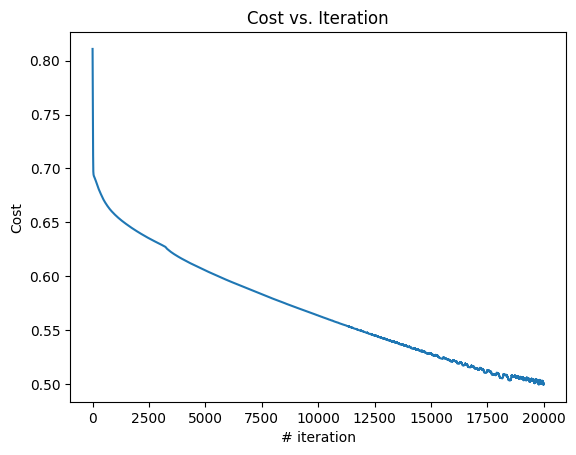

In [16]:
# Plot the Costs vs Iterations chart
show_plot(costs)

In [17]:
# np.save("/kaggle/working/input_mat.npy", X)
# np.save("/kaggle/working/output_mat.npy", Y)
costs[-1]

array(0.49978947)

In [18]:
"""Test the model using test set"""

def perform_inference(file_path, y_true):
    """Performs a forward pass with the Weights & Biases after training for a given file and returns if the predicted output matches with true output."""
    # Initialize and load the input matrix using the given iamge 
    X_test = cp.zeros((200*200*3, 1), dtype=cp.float64)
    X_test[:, 0] = preprocess_file(file_path)

    # Perform forward pass with latest Weights & Biases
    A1, A2, A3 = perform_forward_pass(X_test, W1, B1, W2, B2, W3, B3)

    # Predicts the output as [0,1] 
    y_pred = math.ceil(A3[0][0] - 0.5)
    
    return y_pred == y_true


test_dir_path = "/kaggle/input/cat-and-dog/test_set/test_set"

# test_dir_path = "/kaggle/input/cat-and-dog/training_set/training_set"

total = 0

tn = 0 # True Negative count
fp = 0 # False Positive count
for fname in os.listdir(f"{test_dir_path}/cats")[:500]:
    if "_DS_" in fname:
        continue
    is_correct = perform_inference(f"{test_dir_path}/cats/{fname}", 0)
    tn += int(is_correct)
    fp += int(not is_correct)
    total += 1

tp = 0 # True Positive count
fn = 0 # False Negative count
for fname in os.listdir(f"{test_dir_path}/dogs")[:500]:
    if "_DS_" in fname:
        continue
    is_correct = perform_inference(f"{test_dir_path}/dogs/{fname}", 1)
    tp += int(is_correct)
    fn += int(not is_correct)
    total += 1

print(f"Total: {total}")
print(f"True Positive: {tp}")
print(f"False Positive: {fp}")
print(f"True Negative: {tn}")
print(f"False Negative: {fn}")

Total: 998
True Positive: 264
False Positive: 135
True Negative: 364
False Negative: 235


In [19]:
"""Calculates performance measurement metrics"""

precision = tp/(tp+fp)
recall = tp/(tp+fn)
accuracy = (tp+tn)/(tp+fp+tn+fn)
f1_score = 2*(precision*recall)/(precision+recall)

print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"Accuracy: {accuracy}")
print(f"F1 score: {f1_score}")

Precision: 0.6616541353383458
Recall: 0.5290581162324649
Accuracy: 0.6292585170340681
F1 score: 0.5879732739420934


In [20]:
"""Saves the Weights & Biases into a pickle file."""
# with open('/kaggle/working/binary_classifier.pkl', 'wb') as f:
#   pickle.dump([W1, B1, W2, B2, W3, B3], f)

'Saves the Weights & Biases into a pickle file.'

In [21]:
"""Loads the Weights & Biases from the pickle file."""
# with open('binary_classifier.pkl', 'rb') as f:
  # W1, B1, W2, B2, W3, B3 = pickle.load(f)

'Loads the Weights & Biases from the pickle file.'